In [ ]:
!pip install requests beautifulsoup4 pandas

In [ ]:
!pip install transformers torch nltk

In [ ]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [ ]:
# 1. The Function Definition
def scrape_et_rbi_policy(num_pages=20):
    base_url = "https://economictimes.indiatimes.com/markets/rbi-policy"
    articles = []
    for pg in range(1, num_pages + 1):
        url = f"{base_url}?curpg={pg}"
        res = requests.get(url)
        soup = BeautifulSoup(res.text, "html.parser")
        for entry in soup.find_all("div", class_="eachStory"):
            h3 = entry.find("h3")
            if h3 and h3.find("a"):
                link = "https://economictimes.indiatimes.com" + h3.find("a")["href"]
                title = h3.text.strip()
                summary = entry.find("p").text.strip() if entry.find("p") else ""
                articles.append({"title": title, "url": link, "summary": summary})

        # INCREASED SLEEP TIME to avoid getting blocked on a 20-page pull
        time.sleep(2)

    return pd.DataFrame(articles)

# 2. The Actual Function Call (Execute the Deep Pull)
print("Starting the deep pull... This will take a minute or two.")

# Change this to 20 so it pulls the full history!
df = scrape_et_rbi_policy(num_pages=20)

print(f"Successfully scraped {len(df)} articles.")
print(df.head())

Starting the deep pull... This will take a minute or two.
Successfully scraped 2000 articles.
                                               title  \
0  India bond gains capped by smaller than expect...   
1  June quarter earnings to determine market dire...   
2  Experts see possibility of 50-75 bps RBI rate ...   
3  JP Morgan warns of FY27 earnings risk, says Ni...   
4  Sensex dips 3,400 points in 4 days. Is this th...   

                                                 url  \
0  https://economictimes.indiatimes.comhttps://ec...   
1  https://economictimes.indiatimes.comhttps://ec...   
2  https://economictimes.indiatimes.comhttps://ec...   
3  https://economictimes.indiatimes.comhttps://ec...   
4  https://economictimes.indiatimes.comhttps://ec...   

                                             summary  
0  The benchmark 6.48% 2035 bond yield settled at...  
1  Market expert Sunil Subramaniam advised cautio...  
2  Concerns are rising over India's economic outl...  
3  JP Morgan

In [ ]:
df.to_csv("rbi_policy_news.csv", index=False)


In [ ]:
# 1. Clean up the URL duplication bug
df['url'] = df['url'].str.replace("https://economictimes.indiatimes.comhttps://", "https://")

In [ ]:
df.head(10)

,title,url,summary
0,India bond gains capped by smaller than expect...,https://economictimes.indiatimes.com/markets/b...,The benchmark 6.48% 2035 bond yield settled at...
1,June quarter earnings to determine market dire...,https://economictimes.indiatimes.com/markets/e...,Market expert Sunil Subramaniam advised cautio...
2,Experts see possibility of 50-75 bps RBI rate ...,https://economictimes.indiatimes.com/markets/f...,Concerns are rising over India's economic outl...
3,"JP Morgan warns of FY27 earnings risk, says Ni...",https://economictimes.indiatimes.com/markets/s...,JP Morgan has cautioned that India’s FY27 earn...
4,"Sensex dips 3,400 points in 4 days. Is this th...",https://economictimes.indiatimes.com/markets/s...,Indian equity markets fell for a fourth straig...
5,Turning Defensive! Why bond markets are repric...,https://economictimes.indiatimes.com/markets/b...,Fixed income markets face complexity as global...
6,India to use AI to protect consumers from mone...,https://economictimes.indiatimes.com/wealth/sa...,India will now use Artificial Intelligence to ...
7,"CSB Bank cautious on gold loans, focuses on wh...",https://economictimes.indiatimes.com/markets/e...,CSB Bank is turning cautious on gold loans ami...
8,Is the RBI fighting the wrong battle? Why rate...,https://economictimes.indiatimes.com/markets/s...,Rising oil prices due to the West Asia conflic...
9,Long-term bonds are cheap now; patient investo...,https://economictimes.indiatimes.com/wealth/in...,"Rate cuts are off the table, inflation is cree..."


In [ ]:
df.shape

(2000, 3)

In [ ]:
df['summary'].loc[2]

"Concerns are rising over India's economic outlook due to surging crude oil prices and inflation. Experts suggest the Reserve Bank of India might increase interest rates in the coming quarters. Global uncertainties and geopolitical tensions are adding pressure. While some anticipate a cautious pause, persistent inflation risks could lead to policy tightening."

In [ ]:
# Count rows where summary is NaN
num_nan = df['summary'].isna().sum()
print("Number of NaN summaries:", num_nan)

Number of NaN summaries: 0


In [ ]:
# Number of rows where summary is empty string or only whitespace
num_empty = (df['summary'].str.strip() == '').sum()
print("Number of empty-string summaries:", num_empty)

Number of empty-string summaries: 200


In [ ]:
# 1. Filter out the empty strings and whitespace
df_clean = df[df['summary'].str.strip() != ''].copy()

# 2. Filter out any actual NaN/Null values just to be safe
df_clean = df_clean.dropna(subset=['summary'])

print(f"Original dataset size: {len(df)}")
print(f"Clean dataset size: {len(df_clean)}")

# 3. Overwrite your previous variable so the rest of the pipeline uses the clean data
df = df_clean

Original dataset size: 2000
Clean dataset size: 1800


In [ ]:
import torch
import numpy as np
import pandas as pd
import nltk
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from nltk.tokenize import sent_tokenize

# 1. Download necessary NLTK data (just sentence boundaries, not stopwords!)
nltk.download('punkt')

# 2. Load the FinBERT Model and Tokenizer into memory
print("Loading FinBERT model into memory...")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# 3. Define the Engine
def get_geopolitical_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 'Neutral', 0.0, 0.0, 0.0

    sentences = sent_tokenize(text)

    geopolitical_keywords = ['iran', 'israel', 'us', 'war', 'conflict', 'middle east',
                             'geopolitical', 'crude', 'oil', 'brent']

    pos_scores, neg_scores, neu_scores = [], [], []

    for sentence in sentences:
        if any(keyword in sentence.lower() for keyword in geopolitical_keywords):
            inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=512)

            with torch.no_grad():
                outputs = model(**inputs)

            probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()

            pos_scores.append(probs[0])
            neg_scores.append(probs[1])
            neu_scores.append(probs[2])

    if not pos_scores:
        return 'None', 0.0, 0.0, 0.0

    avg_pos = np.mean(pos_scores)
    avg_neg = np.mean(neg_scores)
    avg_neu = np.mean(neu_scores)

    scores = {'Positive': avg_pos, 'Negative': avg_neg, 'Neutral': avg_neu}
    final_label = max(scores, key=scores.get)

    return final_label, avg_pos, avg_neg, avg_neu

print("Setup Complete! The function is now ready to use.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Loading FinBERT model into memory...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Setup Complete! The function is now ready to use.


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
print("NLTK tokenizers downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK tokenizers downloaded successfully!


In [ ]:
# Run this cell again after downloading punkt_tab!
df[['War_Sentiment_Label', 'War_Pos', 'War_Neg', 'War_Neu']] = df['summary'].apply(
    lambda x: pd.Series(get_geopolitical_sentiment(x))
)

In [ ]:


# 2. Filter down to ONLY the articles that actually mentioned the geopolitical keywords
df_geopolitics = df[df['War_Sentiment_Label'] != 'None'].copy()

# 3. Save this highly valuable, scored dataset so you never have to run the model again!
df_geopolitics.to_csv("rbi_geopolitical_sentiment_scored.csv", index=False)

print(f"\nSUCCESS: Found {len(df_geopolitics)} articles explicitly discussing geopolitical shocks.")
print("Saved to 'rbi_geopolitical_sentiment_scored.csv'")

# View the final scored data
df_geopolitics.head()


SUCCESS: Found 614 articles explicitly discussing geopolitical shocks.
Saved to 'rbi_geopolitical_sentiment_scored.csv'


,title,url,summary,War_Sentiment_Label,War_Pos,War_Neg,War_Neu
1,June quarter earnings to determine market dire...,https://economictimes.indiatimes.com/markets/e...,Market expert Sunil Subramaniam advised cautio...,Positive,0.664999,0.053527,0.281474
2,Experts see possibility of 50-75 bps RBI rate ...,https://economictimes.indiatimes.com/markets/f...,Concerns are rising over India's economic outl...,Negative,0.046669,0.894835,0.058496
3,"JP Morgan warns of FY27 earnings risk, says Ni...",https://economictimes.indiatimes.com/markets/s...,JP Morgan has cautioned that India’s FY27 earn...,Negative,0.022556,0.960659,0.016785
4,"Sensex dips 3,400 points in 4 days. Is this th...",https://economictimes.indiatimes.com/markets/s...,Indian equity markets fell for a fourth straig...,Negative,0.032035,0.944258,0.023707
6,India to use AI to protect consumers from mone...,https://economictimes.indiatimes.com/wealth/sa...,India will now use Artificial Intelligence to ...,Neutral,0.221134,0.014246,0.764620


In [ ]:
import yfinance as yf
import pandas as pd

# Define the tickers for Brent Crude and USD/INR
tickers = ["BZ=F", "INR=X"]

# Pull the data from the start of your RBI scraping period to today
# Adjust the 'start' date to match your earliest scraped RBI document
market_data = yf.download(tickers, start="2022-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))

# We only need the 'Close' prices
market_df = market_data['Close'].reset_index()
market_df.columns = ['Date', 'Brent_Crude', 'USD_INR']

# Ensure Date is in the correct datetime format for merging
market_df['Date'] = pd.to_datetime(market_df['Date']).dt.date

# View the downloaded data
print("Market Data Fetched:")
print(market_df.head())

/tmp/ipykernel_2232/2231559438.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(tickers, start="2022-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))
[*********************100%***********************]  2 of 2 completed

Market Data Fetched:
         Date  Brent_Crude    USD_INR
0  2022-01-03    78.980003  74.513802
1  2022-01-04    80.000000  74.403297
2  2022-01-05    80.800003  74.534897
3  2022-01-06    81.989998  74.430099
4  2022-01-07    81.750000  74.419296


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import json
import yfinance as yf

print("--- STEP 1: Extracting Dates using Advanced JSON-LD ---")
df_geo = df_geopolitics.copy()

def fetch_date_advanced(url):
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        res = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(res.text, 'html.parser')

        # Look for the hidden JSON structured data (This is what Google uses!)
        scripts = soup.find_all('script', type='application/ld+json')
        for script in scripts:
            if script.string:
                try:
                    data = json.loads(script.string)
                    # Data can be a list or a dictionary
                    if isinstance(data, list):
                        for item in data:
                            if 'datePublished' in item:
                                return item['datePublished'][:10] # Grab just YYYY-MM-DD
                    elif isinstance(data, dict):
                        if 'datePublished' in data:
                            return data['datePublished'][:10]
                except:
                    continue

        # Fallback for old articles
        time_tag = soup.find('time')
        if time_tag:
            return time_tag.text
        return "Date Not Found"
    except:
        return "Error"

df_geo['Publish_Date'] = df_geo['url'].apply(fetch_date_advanced)

# Clean the dates
# We strip out "IST" to prevent the Pandas Warning you saw earlier
df_geo['Publish_Date'] = df_geo['Publish_Date'].str.replace(' IST', '', regex=False)
df_geo['Date'] = pd.to_datetime(df_geo['Publish_Date'], errors='coerce', utc=True).dt.date
df_geo_final = df_geo.dropna(subset=['Date']).copy()

print(f"Dates successfully extracted! Found {len(df_geo_final)} valid dates.\n")


print("--- STEP 2: Downloading Expanded Market Data ---")
# We pull data starting from 2010 to make sure we capture EVERY article
tickers = ["BZ=F", "INR=X"]
market_data = yf.download(tickers, start="2010-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))
market_df = market_data['Close'].reset_index()
market_df.columns = ['Date', 'Brent_Crude', 'USD_INR']
market_df['Date'] = pd.to_datetime(market_df['Date']).dt.date


print("--- STEP 3: Merging & Running Econometrics ---")
merged_df = pd.merge(market_df, df_geo_final[['Date', 'War_Neg', 'War_Pos']], on='Date', how='left')

merged_df['War_Neg'] = merged_df['War_Neg'].fillna(0.0)
merged_df['War_Pos'] = merged_df['War_Pos'].fillna(0.0)
merged_df['Lagged_War_Neg'] = merged_df['War_Neg'].shift(1)

final_df = merged_df.dropna().copy()
final_df['Crude_Return'] = final_df['Brent_Crude'].pct_change()
final_df['USD_INR_Return'] = final_df['USD_INR'].pct_change()
model_df = final_df.dropna().copy()

print("================ OLS REGRESSION RESULTS ================")
X = model_df['Lagged_War_Neg']
Y = model_df['USD_INR_Return']

X = sm.add_constant(X)
ols_model = sm.OLS(Y, X).fit()
print(ols_model.summary())
print("\n")

print("================ VAR MODEL SETUP ================")
var_data = model_df[['Crude_Return', 'USD_INR_Return', 'War_Neg']]
var_model = VAR(var_data)
var_results = var_model.fit(maxlags=5, ic='aic')
print(var_results.summary())

--- STEP 1: Extracting Dates using Advanced JSON-LD ---
Dates successfully extracted! Found 562 valid dates.

--- STEP 2: Downloading Expanded Market Data ---


/tmp/ipykernel_2232/3030228015.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market_data = yf.download(tickers, start="2010-01-01", end=pd.Timestamp.today().strftime('%Y-%m-%d'))
[*********************100%***********************]  2 of 2 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


--- STEP 3: Merging & Running Econometrics ---
================ OLS REGRESSION RESULTS ================
                            OLS Regression Results                            
Dep. Variable:         USD_INR_Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.002741
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.958
Time:                        15:32:52   Log-Likelihood:                 16868.
No. Observations:                4293   AIC:                        -3.373e+04
Df Residuals:                    4291   BIC:                        -3.372e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

Generating Professional Portfolio Visualizations...



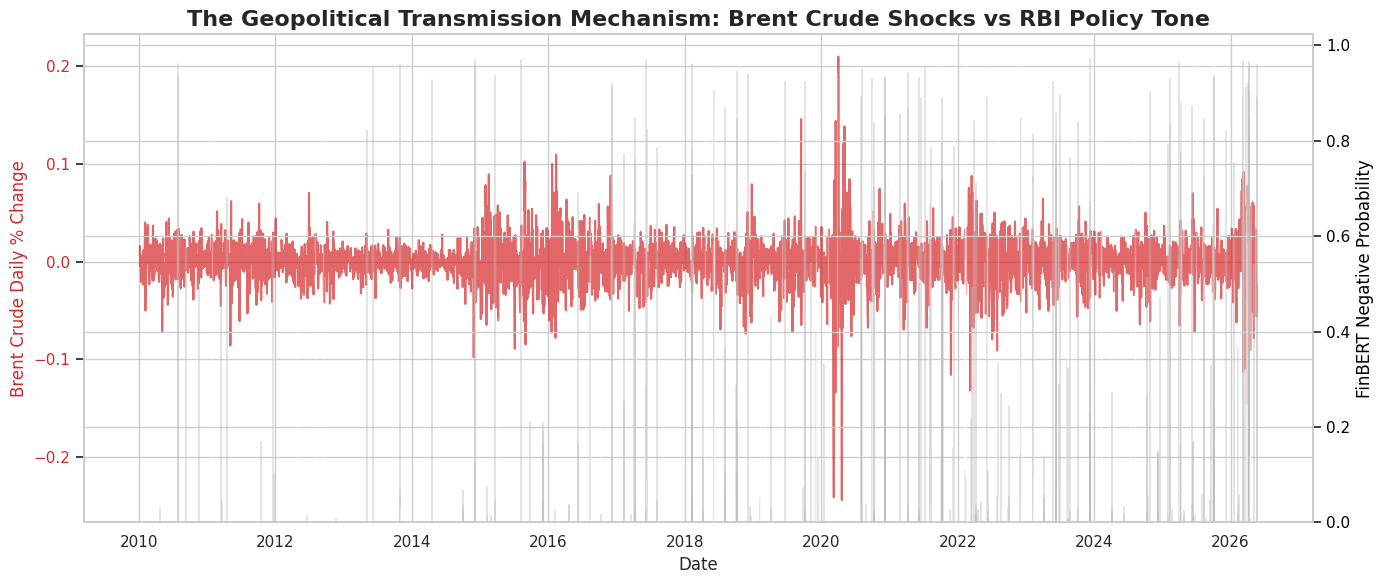

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')

# Set the visual style for a professional look
sns.set_theme(style="whitegrid")

print("Generating Professional Portfolio Visualizations...\n")

# =====================================================================
# VISUALIZATION 1: Macro Shock Dual-Axis Line Chart (The VAR Story)
# Shows how Oil Volatility spikes, followed by RBI negative sentiment
# =====================================================================
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Brent Crude Returns (Red Line)
ax1.plot(model_df['Date'], model_df['Crude_Return'], color='#D62728', alpha=0.7, linewidth=1.5, label='Brent Crude Volatility')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Brent Crude Daily % Change', color='#D62728', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#D62728')

# Plot 2: RBI Negative Sentiment (Black Bars overlay)
ax2 = ax1.twinx()
ax2.bar(model_df['Date'], model_df['War_Neg'], color='black', alpha=0.3, width=3, label='RBI Hawkish/Negative Sentiment')
ax2.set_ylabel('FinBERT Negative Probability', color='black', fontsize=12)
ax2.tick_params(axis='y', labelcolor='black')

plt.title('The Geopolitical Transmission Mechanism: Brent Crude Shocks vs RBI Policy Tone', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

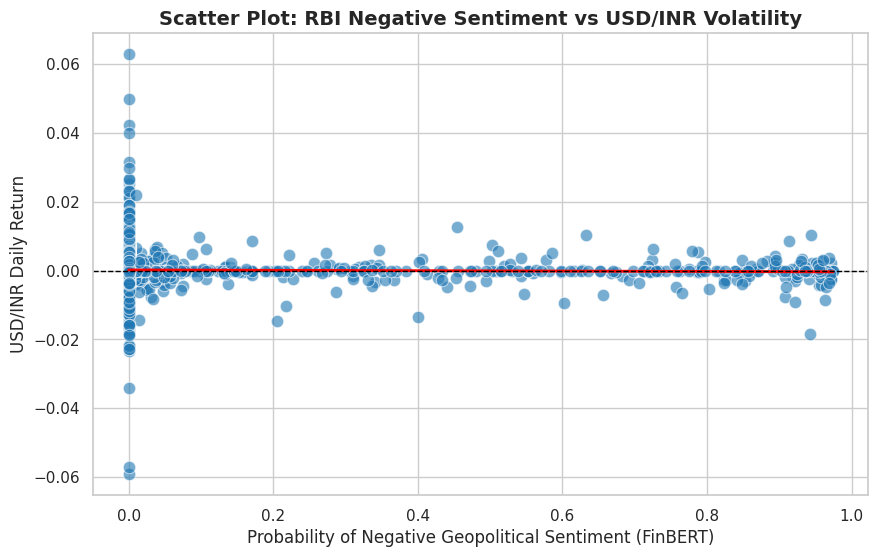

In [ ]:
# =====================================================================
# VISUALIZATION 2: Sentiment vs Volatility Scatter Plot
# Shows the exact correlation cluster between tone and market reaction
# =====================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=model_df, x='War_Neg', y='USD_INR_Return', color='#1F77B4', alpha=0.6, s=80)

# Add a trend line
sns.regplot(data=model_df, x='War_Neg', y='USD_INR_Return', scatter=False, color='red', line_kws={"linewidth": 2})

plt.title('Scatter Plot: RBI Negative Sentiment vs USD/INR Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Probability of Negative Geopolitical Sentiment (FinBERT)', fontsize=12)
plt.ylabel('USD/INR Daily Return', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Neutral zero line
plt.show()

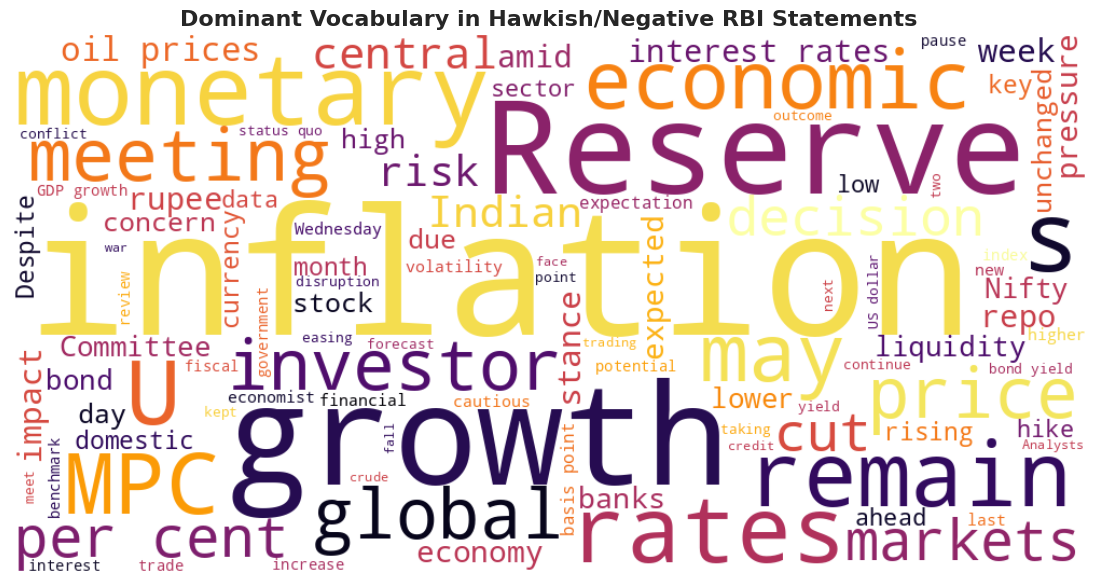

In [ ]:
# =====================================================================
# VISUALIZATION 3: The Geopolitical Word Clouds
# What specific words was the RBI using when they were worried?
# =====================================================================
# We isolate the text from articles where FinBERT labeled the sentiment as Negative
negative_articles = df_geo_final[df_geo_final['War_Sentiment_Label'] == 'Negative']['summary'].astype(str)
negative_text = " ".join(negative_articles)

# We define a strict list of Stopwords for the visual so it looks clean
# We add common web scraping noise words to the standard list
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['said', 'will', 'say', 'india', 'rbi', 'bank', 'rate', 'policy', 'market', 'year', 'percent'])

# Generate the Word Cloud
if len(negative_text.strip()) > 0:
    wordcloud_neg = WordCloud(width=1000, height=500,
                              background_color='white',
                              stopwords=custom_stopwords,
                              colormap='inferno', # 'inferno' gives a great red/orange "warning" look
                              max_words=100).generate(negative_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title('Dominant Vocabulary in Hawkish/Negative RBI Statements', fontsize=16, fontweight='bold')
    plt.show()
else:
    print("Not enough purely negative text to generate a word cloud.")